In [2]:
import treecorr
import numpy as np
import matplotlib.pyplot as plt
import os
from astropy.io import fits
#import fitsio
from astropy.table import Table
#import csv 
import pandas as pd
import polars as pl

try:
    plt.style.use('/home/dy9683/cosmic-shear/cosmic-shear-with-spec-z/paperfigs.mplstyle')
except Exception as e:
    print(f'Error: {e}')
    # print(f"Could not find style file paperfigs.mplstyle")

# Load Catalog

KiDS Legacy Matched from Jared

In [3]:
kidslegacy = '/scratch/gpfs/js1998/matched_catalogs/kidslegacy_matched.csv'

In [4]:
file_path = kidslegacy
kidslegacy_catalog = pl.scan_csv(file_path).filter(pl.col('lensing_match') == 1).collect()

In [5]:
kidslegacy_catalog

,TARGETID,SURVEY,PROGRAM,TILEID,LASTNIGHT,Z_BEST,Z_CONF,ZERR_BEST,ZWARN_BEST,SPECTYPE_BEST,SUBTYPE_BEST,CHI2_BEST,DELTACHI2_BEST,PETAL_LOC,FIBER,COADD_FIBERSTATUS,TARGET_RA,TARGET_DEC,DESINAME,OBJTYPE,FIBERASSIGN_X,FIBERASSIGN_Y,PRIORITY,COADD_NUMEXP,COADD_EXPTIME,COADD_NUMNIGHT,COADD_NUMTILE,MIN_MJD,MAX_MJD,MEAN_MJD,GOOD_SPEC,EFFTIME_SPEC,ZCAT_NSPEC,ZCAT_PRIMARY,SV_NSPEC,SV_PRIMARY,MAIN_NSPEC,MAIN_PRIMARY,CMX_TARGET,DESI_TARGET,BGS_TARGET,MWS_TARGET,SCND_TARGET,SV1_DESI_TARGET,SV1_BGS_TARGET,SV1_MWS_TARGET,SV1_SCND_TARGET,SV2_DESI_TARGET,SV2_BGS_TARGET,SV2_MWS_TARGET,SV2_SCND_TARGET,SV3_DESI_TARGET,SV3_BGS_TARGET,SV3_MWS_TARGET,SV3_SCND_TARGET,lensing_ra,lensing_dec,e1,e2,lensing_weight,lensing_match
i64,i64,str,str,i64,i64,f64,i64,f64,i64,str,str,f64,f64,i64,i64,i64,f64,f64,str,str,f64,f64,i64,i64,f64,i64,i64,f64,f64,f64,bool,f64,i64,bool,i64,bool,i64,bool,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,i64
266679,-415623282,"""b'main'""","""b'backup'""",41562,20220127,1.477694,0,0.000195,2049,"""b'GALAXY'""",null,7260.14,26.706469,3,1679,1026,184.246568,-0.43302,"""b'DESI J184.2465-00.4330'""","""b'SKY'""",293.1321,69.82538,0,1,602.914,1,1,59607.461471,59607.461471,59607.461471,false,443.7908,1,true,0,false,1,true,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,184.246639,-0.432775,-0.17223,-0.209533,15.525585,1
266867,-415623456,"""b'main'""","""b'backup'""",41562,20220127,1.478692,0,0.000128,2049,"""b'GALAXY'""",null,7936.817,56.07819,3,1867,1026,184.145688,-0.048595,"""b'DESI J184.1456-00.0485'""","""b'SKY'""",321.58896,167.23294,0,1,602.914,1,1,59607.461471,59607.461471,59607.461471,false,390.58182,1,true,0,false,1,true,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,184.145427,-0.048595,0.025807,0.529159,2.787837,1
267023,616088546163294601,"""b'main'""","""b'backup'""",41562,20220127,0.11445,0,0.000057,5,"""b'GALAXY'""",null,7118.339,1.1101948,4,2023,0,184.438645,0.204332,"""b'DESI J184.4386+00.2043'""","""b'SKY'""",246.82294,229.86523,-1,1,602.914,1,1,59607.461471,59607.461471,59607.461471,false,70.61572,2,false,0,false,1,true,0,4294967296,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,184.438489,0.20423,-0.436949,0.286651,1.868659,1
267070,-415624308,"""b'main'""","""b'backup'""",41562,20220127,1.197444,0,0.000077,5,"""b'GALAXY'""",null,7367.308,5.0560617,4,2070,2,184.908504,0.367203,"""b'DESI J184.9085+00.3672'""","""b'SKY'""",128.33734,268.97327,0,1,602.914,1,1,59607.461471,59607.461471,59607.461471,false,1230.3533,1,true,0,false,1,true,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,184.908667,0.367106,0.231688,-0.202664,14.865519,1
267326,-415624430,"""b'main'""","""b'backup'""",41562,20220127,1.662837,0,0.000009,2049,"""b'GALAXY'""",null,6749.0527,210.51732,4,2326,1026,184.67362,0.486301,"""b'DESI J184.6736+00.4863'""","""b'SKY'""",188.59402,301.4623,0,1,602.914,1,1,59607.461471,59607.461471,59607.461471,false,377.2222,1,true,0,false,1,true,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,184.673672,0.486502,-0.041655,-0.188208,0.626701,1
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
120373491,39627752067827478,"""b'sv3'""","""b'dark'""",521,20210610,1.013174,3,0.000109,0,"""b'GALAXY'""",null,7437.432,50.0913,9,4991,0,213.329409,-1.513757,"""b'DESI J213.3294-01.5137'""","""b'TGT'""",-108.30537,-205.67491,2,1,1378.7407,1,1,59376.205552,59376.205552,59376.205552,true,1001.1982,3,true,2,true,0,false,0,0,0,0,0,0,0,0,0,0,0,0,0,655394,0,0,0,213.329457,-1.513777,-0.463034,0.320295,12.854184,1
120373492,39627746028028710,"""b'sv3'""","""b'dark'""",521,20210610,0.468845,0,0.000103,4,"""b'GALAXY'""",null,7531.9287,0.204528,9,4992,0,213.284541,-1.655693,"""b'DESI J213.2845-01.6556'""","""b'TGT'""",-97.637314,-241.55595,83100,1,1378.7407,1,1,59376.205552,59376.205552,59376.205552,true,954.587,4,false,3,false,0,false,0,0,0,0,0,0,0,0,0,0,0,0,0,1179714,0,0,0,213.284615,-1.655703,-0.029469,-0.368369,3.044955,1
120373495,39627752067831529,"""b'sv3'""","""b'dark'""",521,20210610,2.3571

In [6]:
ra = kidslegacy_catalog['TARGET_RA']
dec = kidslegacy_catalog['TARGET_DEC']
g1 = kidslegacy_catalog['e1'] 
g2 = kidslegacy_catalog['e2']
z = kidslegacy_catalog['Z_BEST']

# Plots

In [7]:
print(f'Number of sources: {len(kidslegacy_catalog):,}')

Number of sources: 1,327,900


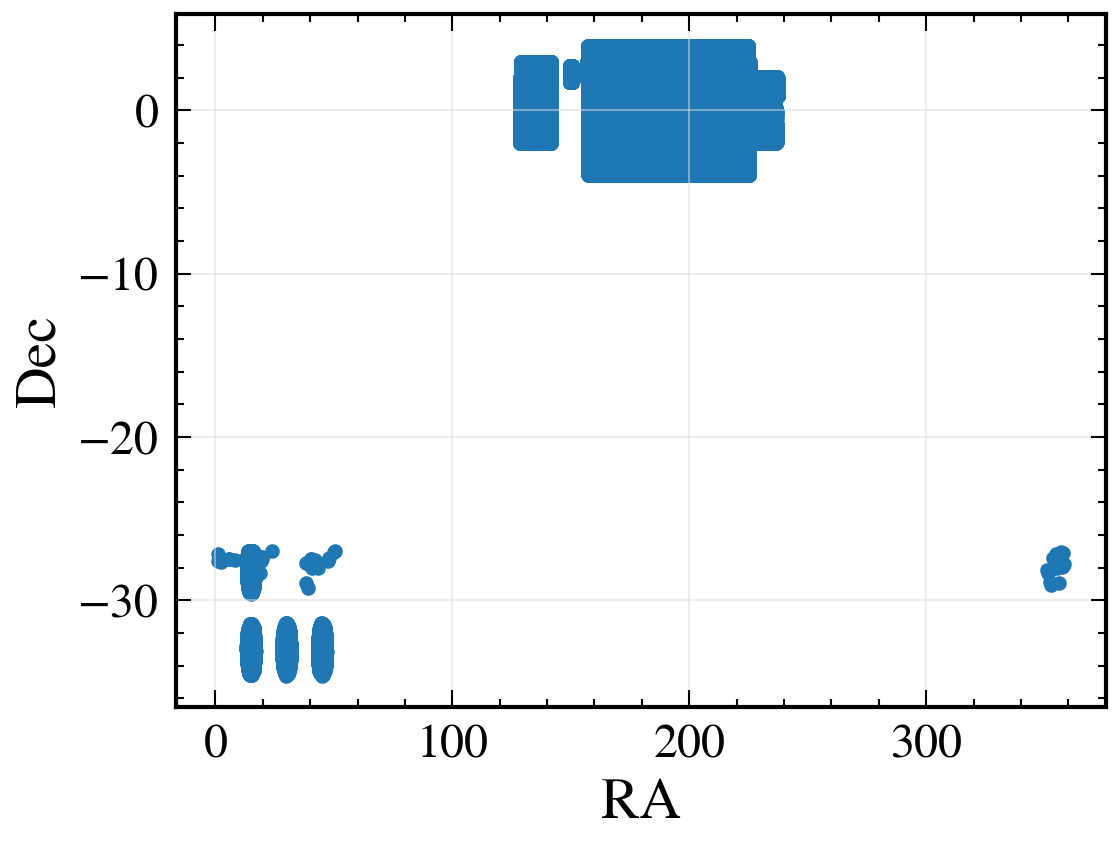

In [8]:
# ra v dec
fig, ax = plt.subplots(figsize = (8,6))
ax.scatter(ra, dec)
ax.set_xlabel("RA")
ax.set_ylabel("Dec")
#ax.set_xlim(0, 360)
#ax.set_ylim(-30, 30)
plt.show()

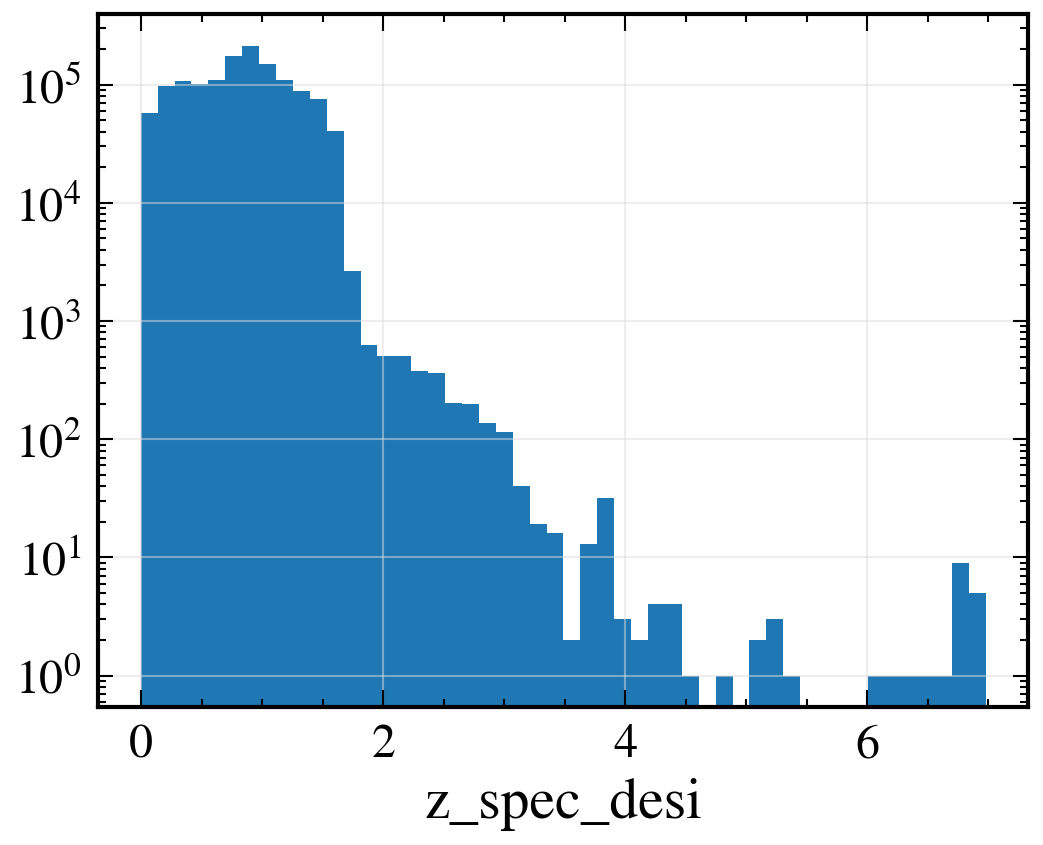

In [9]:
# histogram of redshifts
fig, ax = plt.subplots(figsize = (8,6))
ax.hist(z, bins = 50 , density = False)
ax.set_xlabel("z_spec_desi")
ax.set_yscale('log')
plt.show()

# TreeCorr Calculations

https://rmjarvis.github.io/TreeCorr/_build/html/gg.html

In [10]:
cat = treecorr.Catalog(ra=ra, dec=dec, g1=g1, g2=g2, ra_units='degrees', dec_units='degrees')
gg = treecorr.GGCorrelation(min_sep=1.0, max_sep=100.0, nbins=20, sep_units='arcmin')
gg.process(cat)

r = np.exp(gg.meanlogr)

# correlation functions
#xi_+
xip = gg.xip
# # xi_-
xim = gg.xim

#calculate variance
sig_xip = np.sqrt(gg.varxip)
sig_xim = np.sqrt(gg.varxim)

# $\xi_{+/-}$ Plot

In [11]:
xip

array([ 4.41638155e-04, -2.96102286e-04, -9.76862369e-05,  8.30071248e-05,
       -1.12312342e-05,  8.63819936e-05, -5.64994506e-05,  7.83022237e-06,
        3.71948673e-05,  2.82017603e-05, -1.96128702e-05,  4.12159829e-05,
        8.72731836e-06,  6.28798071e-06,  4.56219378e-06,  8.33805899e-06,
        4.78070306e-07,  4.20836852e-07,  9.60970032e-06,  8.06551001e-06])

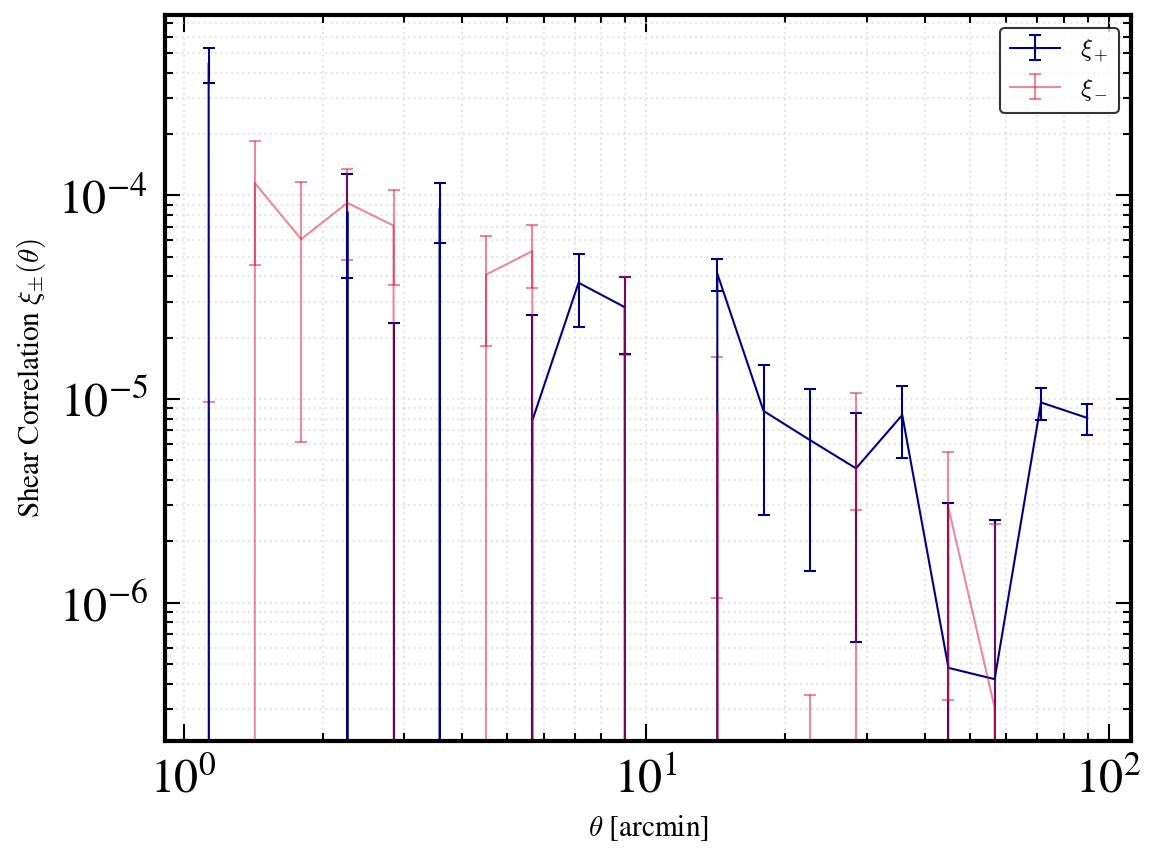

In [12]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.errorbar(r, xip, yerr=sig_xip, label=r'$\xi_+$', color='navy', capsize=3)
ax.errorbar(r, xim, yerr=sig_xim, label=r'$\xi_-$', color='crimson', capsize=3, alpha = 0.5)

ax.set_xscale('log')
ax.set_yscale('log') 
ax.set_xlabel(r'$\theta$ [arcmin]', fontsize=14)
ax.set_ylabel(r'Shear Correlation $\xi_{\pm}(\theta)$', fontsize=14)
ax.legend(fontsize=12)
ax.grid(True, which='both', linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

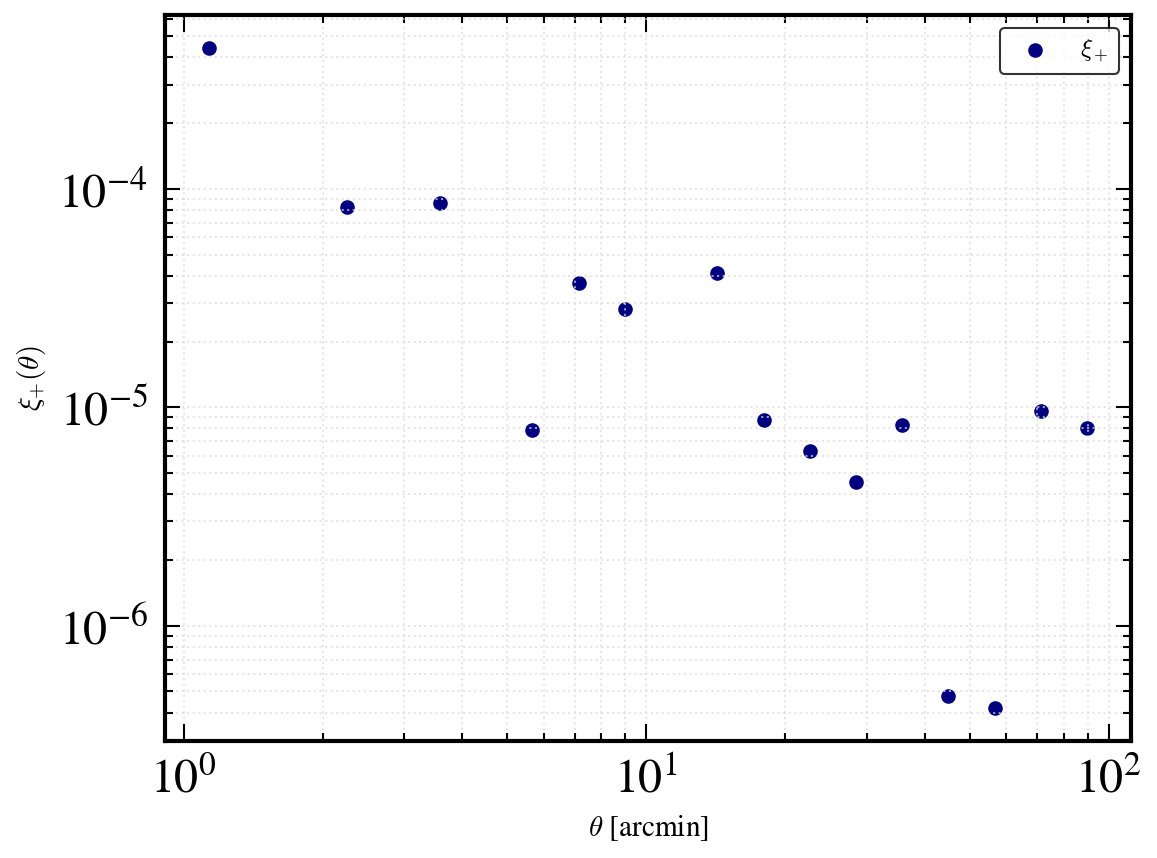

In [13]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(r, xip, label=r'$\xi_+$', color='navy')

ax.set_xscale('log')
ax.set_yscale('log') 
ax.set_xlabel(r'$\theta$ [arcmin]', fontsize=14)
ax.set_ylabel(r'$\xi_{+}(\theta)$', fontsize=14)
ax.legend(fontsize=12)
ax.grid(True, which='both', linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()